# Indian Equity Portfolio Risk Engine
## Phase 3 — Portfolio Optimization & Efficient Frontier

**What this notebook covers:**
- Modern Portfolio Theory (MPT) — Markowitz framework
- Efficient Frontier construction via Monte Carlo simulation
- Minimum Variance Portfolio (MVP)
- Maximum Sharpe Ratio Portfolio (Tangency Portfolio)
- Scipy-based exact optimization (not just simulation)
- Benchmark comparison vs Nifty 50
- Portfolio weights visualization

**Why this matters in interviews:**
MPT is the foundation of modern asset management. Every AM, IB, and quant role
will expect you to explain the efficient frontier, diversification, and the
risk-return tradeoff. Having built it from scratch on real Indian data is a
strong differentiator.

---

In [3]:
# ── Cell 1: Imports & load Phase 2 outputs ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/portfolio_project/'

# Load outputs from Phase 1 & 2
log_returns       = pd.read_csv(SAVE_PATH + 'log_returns.csv', index_col=0, parse_dates=True)
benchmark_returns = pd.read_csv(SAVE_PATH + 'benchmark_returns.csv', index_col=0, parse_dates=True)
risk_metrics      = pd.read_csv(SAVE_PATH + 'risk_metrics.csv', index_col=0)

# Constants
TRADING_DAYS         = 250
RISK_FREE_RATE_ANNUAL = 0.065
RISK_FREE_DAILY      = RISK_FREE_RATE_ANNUAL / TRADING_DAYS

# Clean up ticker names for display
log_returns.columns = log_returns.columns.str.replace('.NS', '', regex=False)

# Squeeze benchmark to Series if needed
if isinstance(benchmark_returns, pd.DataFrame):
    benchmark_returns = benchmark_returns.squeeze()

print(f'Log returns loaded : {log_returns.shape}')
print(f'Stocks in universe : {log_returns.shape[1]}')
print(f'Date range         : {log_returns.index[0]} to {log_returns.index[-1]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Log returns loaded : (1728, 50)
Stocks in universe : 50
Date range         : 2019-01-02 00:00:00 to 2025-12-30 00:00:00


In [4]:
# ── Cell 2: Build mean & covariance inputs ────────────────────────────────
# These two inputs are ALL that Markowitz MPT needs:
#   1. Expected returns (mean daily return, annualised)
#   2. Covariance matrix (how stocks move together)
#
# The covariance matrix captures both individual volatilities AND
# correlations between every pair of stocks simultaneously

# Annualised mean returns
mean_returns = log_returns.mean() * TRADING_DAYS

# Annualised covariance matrix
cov_matrix = log_returns.cov() * TRADING_DAYS

n_assets = len(mean_returns)

print(f'Number of assets   : {n_assets}')
print(f'\nTop 5 expected annual returns:')
print((mean_returns.sort_values(ascending=False).head(5) * 100).round(2).to_string())
print(f'\nCovariance matrix shape: {cov_matrix.shape}')
print(f'(Each cell = annualised covariance between two stocks)')

Number of assets   : 50

Top 5 expected annual returns:
ADANIENT      38.45
BHARTIARTL    29.13
TATACONSUM    25.17
APOLLOHOSP    24.99
M&M           23.43

Covariance matrix shape: (50, 50)
(Each cell = annualised covariance between two stocks)


In [5]:
# ── Cell 3: Portfolio metrics function ────────────────────────────────────
# Given a set of weights, this function computes:
#   - Portfolio return
#   - Portfolio volatility
#   - Portfolio Sharpe ratio
#
# This is the core engine that everything else calls

def portfolio_metrics(weights, mean_returns, cov_matrix, rf=RISK_FREE_RATE_ANNUAL):
    """
    Compute annualised return, volatility, and Sharpe ratio for a portfolio.

    weights     : array of portfolio weights (must sum to 1)
    mean_returns: annualised expected returns per asset
    cov_matrix  : annualised covariance matrix
    rf          : annual risk-free rate

    Returns: (return, volatility, sharpe)
    """
    weights = np.array(weights)

    # Portfolio return = weighted sum of individual returns
    port_return = np.dot(weights, mean_returns)

    # Portfolio variance = w' * Σ * w  (matrix multiplication)
    # This is where diversification happens — low correlations reduce variance
    port_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    port_vol = np.sqrt(port_variance)

    # Sharpe ratio
    sharpe = (port_return - rf) / port_vol

    return port_return, port_vol, sharpe

# Quick test: equal-weight portfolio
equal_weights = np.array([1 / n_assets] * n_assets)
eq_ret, eq_vol, eq_sharpe = portfolio_metrics(equal_weights, mean_returns, cov_matrix)

print('Equal-weight portfolio (1/N benchmark):')
print(f'  Annual return : {eq_ret*100:.2f}%')
print(f'  Annual vol    : {eq_vol*100:.2f}%')
print(f'  Sharpe ratio  : {eq_sharpe:.3f}')

Equal-weight portfolio (1/N benchmark):
  Annual return : 16.18%
  Annual vol    : 17.51%
  Sharpe ratio  : 0.553


In [6]:
# ── Cell 4: Monte Carlo simulation — random portfolios ────────────────────
# Generate 10,000 random weight combinations to map out the
# risk-return space. This SHOWS the efficient frontier visually.
#
# Every dot = one possible portfolio
# The frontier is the LEFT EDGE of this cloud
# No portfolio can exist to the LEFT of the frontier (impossible)
# No rational investor should be BELOW the frontier (inefficient)

N_PORTFOLIOS = 10000
np.random.seed(42)

results = np.zeros((3, N_PORTFOLIOS))   # rows: return, vol, sharpe
weights_store = np.zeros((N_PORTFOLIOS, n_assets))

print(f'Simulating {N_PORTFOLIOS:,} random portfolios...')

for i in range(N_PORTFOLIOS):
    # Random weights that sum to 1 (Dirichlet distribution)
    w = np.random.dirichlet(np.ones(n_assets))
    ret, vol, sharpe = portfolio_metrics(w, mean_returns, cov_matrix)
    results[0, i] = ret
    results[1, i] = vol
    results[2, i] = sharpe
    weights_store[i] = w

results_df = pd.DataFrame({
    'Return'     : results[0],
    'Volatility' : results[1],
    'Sharpe'     : results[2]
})

print(f'Done.')
print(f'Return range  : {results_df.Return.min()*100:.1f}% to {results_df.Return.max()*100:.1f}%')
print(f'Vol range     : {results_df.Volatility.min()*100:.1f}% to {results_df.Volatility.max()*100:.1f}%')
print(f'Sharpe range  : {results_df.Sharpe.min():.2f} to {results_df.Sharpe.max():.2f}')

Simulating 10,000 random portfolios...
Done.
Return range  : 12.0% to 21.7%
Vol range     : 15.7% to 21.6%
Sharpe range  : 0.27 to 0.76


In [7]:
# ── Cell 5: Scipy optimization — Minimum Variance Portfolio ───────────────
# Monte Carlo gives us a picture but is imprecise.
# Scipy finds the EXACT mathematical optimum.
#
# Minimum Variance Portfolio (MVP):
#   Find weights that MINIMISE portfolio volatility
#   Subject to: weights sum to 1, each weight >= 0 (no short selling)
#
# This is the leftmost point on the efficient frontier

def neg_sharpe(weights):
    """Returns negative Sharpe — scipy minimizes, so we negate to maximize."""
    return -portfolio_metrics(weights, mean_returns, cov_matrix)[2]

def portfolio_vol(weights):
    """Returns portfolio volatility."""
    return portfolio_metrics(weights, mean_returns, cov_matrix)[1]

# Constraints: weights must sum to 1
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

# Bounds: each weight between 0% and 100% (long-only, no shorting)
bounds = tuple((0, 1) for _ in range(n_assets))

# Starting point: equal weights
w0 = equal_weights

# ── Minimize Volatility ──
mvp_result = minimize(
    portfolio_vol,
    w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-12}
)

mvp_weights = mvp_result.x
mvp_ret, mvp_vol, mvp_sharpe = portfolio_metrics(mvp_weights, mean_returns, cov_matrix)

print('=== Minimum Variance Portfolio (MVP) ===')
print(f'Annual return  : {mvp_ret*100:.2f}%')
print(f'Annual vol     : {mvp_vol*100:.2f}%')
print(f'Sharpe ratio   : {mvp_sharpe:.3f}')
print(f'Optimizer status: {mvp_result.message}')

# Top holdings
mvp_weights_df = pd.Series(mvp_weights, index=log_returns.columns)
print(f'\nTop 10 holdings (MVP):')
print((mvp_weights_df.sort_values(ascending=False).head(10) * 100).round(2).to_string())

=== Minimum Variance Portfolio (MVP) ===
Annual return  : 13.37%
Annual vol     : 13.61%
Sharpe ratio   : 0.505
Optimizer status: Optimization terminated successfully

Top 10 holdings (MVP):
TCS           12.22
NESTLEIND     10.58
ITC           10.08
CIPLA          8.94
DRREDDY        8.88
POWERGRID      8.84
HINDUNILVR     7.58
HDFCBANK       7.15
BRITANNIA      5.92
ASIANPAINT     3.93


In [8]:
# ── Cell 6: Scipy optimization — Maximum Sharpe Portfolio ─────────────────
# Maximum Sharpe Portfolio (Tangency Portfolio):
#   Find weights that MAXIMISE Sharpe ratio
#   = best risk-adjusted return
#   = the portfolio where a line from the risk-free rate is TANGENT
#     to the efficient frontier (Capital Market Line)
#
# This is the portfolio a rational investor should hold
# (combined with cash/leverage to get desired risk level)

msr_result = minimize(
    neg_sharpe,
    w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-12}
)

msr_weights = msr_result.x
msr_ret, msr_vol, msr_sharpe = portfolio_metrics(msr_weights, mean_returns, cov_matrix)

print('=== Maximum Sharpe Ratio Portfolio (Tangency Portfolio) ===')
print(f'Annual return  : {msr_ret*100:.2f}%')
print(f'Annual vol     : {msr_vol*100:.2f}%')
print(f'Sharpe ratio   : {msr_sharpe:.3f}')
print(f'Optimizer status: {msr_result.message}')

# Top holdings
msr_weights_df = pd.Series(msr_weights, index=log_returns.columns)
print(f'\nTop 10 holdings (Max Sharpe):')
print((msr_weights_df.sort_values(ascending=False).head(10) * 100).round(2).to_string())

=== Maximum Sharpe Ratio Portfolio (Tangency Portfolio) ===
Annual return  : 25.87%
Annual vol     : 18.47%
Sharpe ratio   : 1.048
Optimizer status: Optimization terminated successfully

Top 10 holdings (Max Sharpe):
BHARTIARTL    29.43
TATACONSUM    12.65
APOLLOHOSP    11.31
HCLTECH        9.24
ADANIENT       8.86
SUNPHARMA      8.70
DIVISLAB       7.59
TITAN          5.57
BAJAJ-AUTO     3.96
POWERGRID      2.68


In [9]:
# ── Cell 7: Build the efficient frontier curve ────────────────────────────
# The frontier = set of portfolios with MINIMUM vol for each return level
# We trace it by optimizing at 50 different target return levels

def min_vol_for_target_return(target_return):
    """Find minimum volatility portfolio that achieves a target return."""
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_metrics(w, mean_returns, cov_matrix)[0] - target_return}
    ]
    result = minimize(
        portfolio_vol, w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 500, 'ftol': 1e-10}
    )
    if result.success:
        return portfolio_metrics(result.x, mean_returns, cov_matrix)
    return None

# Target returns: range from MVP return to max possible return
target_returns = np.linspace(mvp_ret, mean_returns.max() * 0.95, 50)

frontier_vols    = []
frontier_returns = []

print('Tracing efficient frontier...')
for tr in target_returns:
    result = min_vol_for_target_return(tr)
    if result:
        frontier_returns.append(result[0])
        frontier_vols.append(result[1])

print(f'Frontier points computed: {len(frontier_returns)}')

Tracing efficient frontier...
Frontier points computed: 50


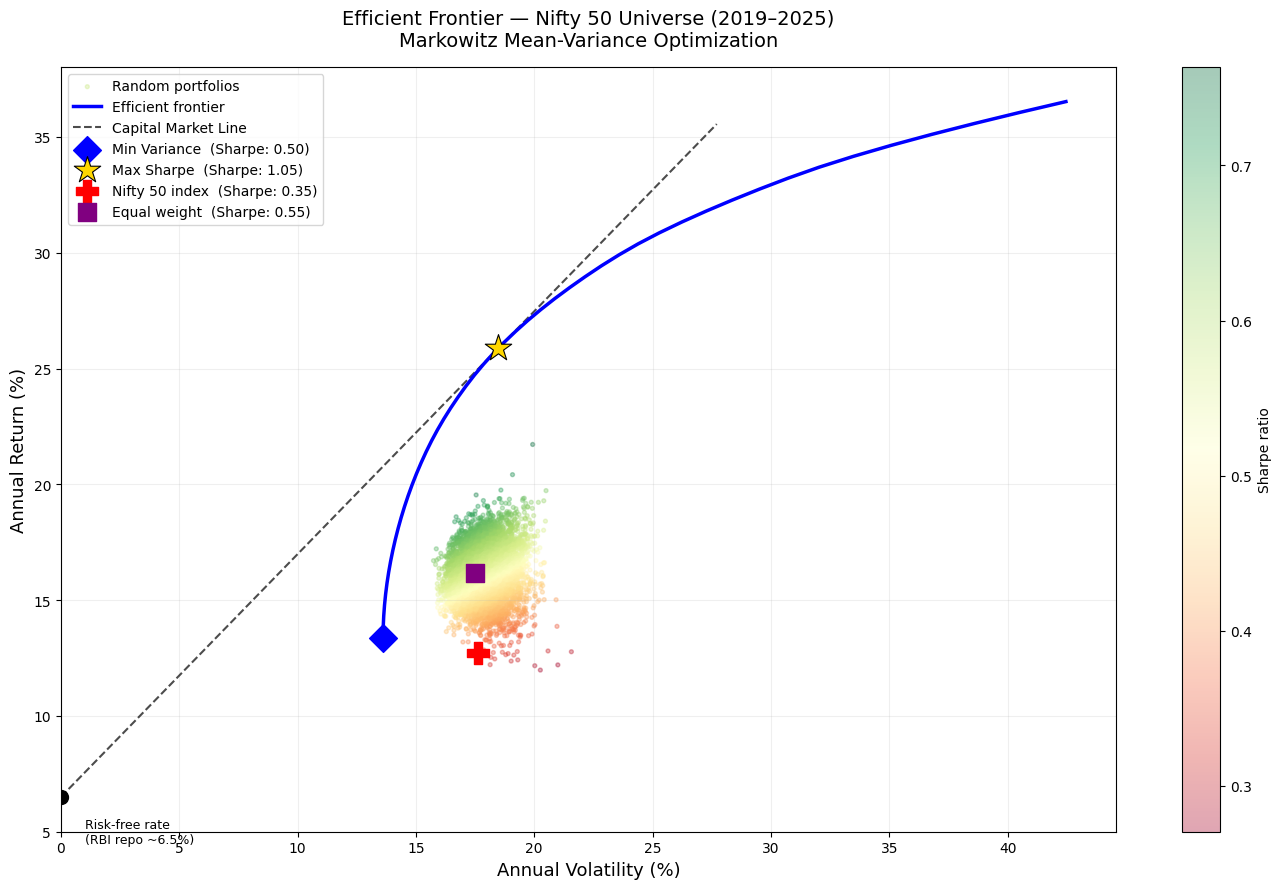

Chart saved to Google Drive.


In [10]:
# ── Cell 8: The main chart — Efficient Frontier ───────────────────────────
# This is the signature chart of your project
# Every interviewer will recognise it immediately

# Nifty 50 benchmark metrics
bench_ret = float(benchmark_returns.mean()) * TRADING_DAYS
bench_vol = float(benchmark_returns.std()) * np.sqrt(TRADING_DAYS)
bench_sharpe = (bench_ret - RISK_FREE_RATE_ANNUAL) / bench_vol

# Equal weight portfolio metrics
eq_ret, eq_vol, eq_sharpe = portfolio_metrics(equal_weights, mean_returns, cov_matrix)

fig, ax = plt.subplots(figsize=(14, 9))

# 1. Random portfolios (Monte Carlo cloud)
sc = ax.scatter(
    results_df['Volatility'] * 100,
    results_df['Return'] * 100,
    c=results_df['Sharpe'],
    cmap='RdYlGn',
    alpha=0.35, s=8,
    label='Random portfolios'
)
plt.colorbar(sc, ax=ax, label='Sharpe ratio')

# 2. Efficient frontier line
ax.plot(
    [v * 100 for v in frontier_vols],
    [r * 100 for r in frontier_returns],
    'b-', linewidth=2.5, label='Efficient frontier', zorder=5
)

# 3. Capital Market Line (from risk-free rate through Max Sharpe point)
cml_x = np.linspace(0, msr_vol * 1.5, 100)
cml_y = RISK_FREE_RATE_ANNUAL + msr_sharpe * cml_x
ax.plot(cml_x * 100, cml_y * 100, 'k--', linewidth=1.5,
        alpha=0.7, label='Capital Market Line')

# 4. Key portfolios
ax.scatter(mvp_vol * 100, mvp_ret * 100,
           marker='D', s=200, color='blue', zorder=10,
           label=f'Min Variance  (Sharpe: {mvp_sharpe:.2f})')

ax.scatter(msr_vol * 100, msr_ret * 100,
           marker='*', s=400, color='gold', edgecolors='black',
           linewidth=0.8, zorder=10,
           label=f'Max Sharpe  (Sharpe: {msr_sharpe:.2f})')

ax.scatter(bench_vol * 100, bench_ret * 100,
           marker='P', s=250, color='red', zorder=10,
           label=f'Nifty 50 index  (Sharpe: {bench_sharpe:.2f})')

ax.scatter(eq_vol * 100, eq_ret * 100,
           marker='s', s=150, color='purple', zorder=10,
           label=f'Equal weight  (Sharpe: {eq_sharpe:.2f})')

# 5. Risk-free rate point
ax.scatter(0, RISK_FREE_RATE_ANNUAL * 100,
           marker='o', s=100, color='black', zorder=10)
ax.annotate('Risk-free rate\n(RBI repo ~6.5%)',
            (0, RISK_FREE_RATE_ANNUAL * 100),
            xytext=(1, RISK_FREE_RATE_ANNUAL * 100 - 2),
            fontsize=9)

ax.set_xlabel('Annual Volatility (%)', fontsize=13)
ax.set_ylabel('Annual Return (%)', fontsize=13)
ax.set_title('Efficient Frontier — Nifty 50 Universe (2019–2025)\nMarkowitz Mean-Variance Optimization',
             fontsize=14, pad=15)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.2)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig(SAVE_PATH + 'efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to Google Drive.')

In [11]:
# ── Cell 9: Portfolio comparison summary table ─────────────────────────────
# Clean comparison of all 4 portfolios — great slide for your presentation

comparison = pd.DataFrame({
    'Portfolio'      : ['Min Variance', 'Max Sharpe', 'Equal Weight', 'Nifty 50 (benchmark)'],
    'Annual Return %': [
        round(mvp_ret * 100, 2),
        round(msr_ret * 100, 2),
        round(eq_ret  * 100, 2),
        round(bench_ret * 100, 2)
    ],
    'Annual Vol %'   : [
        round(mvp_vol * 100, 2),
        round(msr_vol * 100, 2),
        round(eq_vol  * 100, 2),
        round(bench_vol * 100, 2)
    ],
    'Sharpe Ratio'   : [
        round(mvp_sharpe, 3),
        round(msr_sharpe, 3),
        round(eq_sharpe,  3),
        round(bench_sharpe, 3)
    ]
}).set_index('Portfolio')

print('=== Portfolio Comparison ===')
print(comparison.to_string())
print()
print(f'Max Sharpe outperforms Nifty 50 by: '
      f'{(msr_sharpe - bench_sharpe):.3f} Sharpe points')
print(f'Min Variance reduces vol vs Nifty 50 by: '
      f'{(bench_vol - mvp_vol)*100:.2f} percentage points')

comparison.to_csv(SAVE_PATH + 'portfolio_comparison.csv')

=== Portfolio Comparison ===
                      Annual Return %  Annual Vol %  Sharpe Ratio
Portfolio                                                        
Min Variance                    13.37         13.61         0.505
Max Sharpe                      25.87         18.47         1.048
Equal Weight                    16.18         17.51         0.553
Nifty 50 (benchmark)            12.71         17.63         0.352

Max Sharpe outperforms Nifty 50 by: 0.696 Sharpe points
Min Variance reduces vol vs Nifty 50 by: 4.02 percentage points


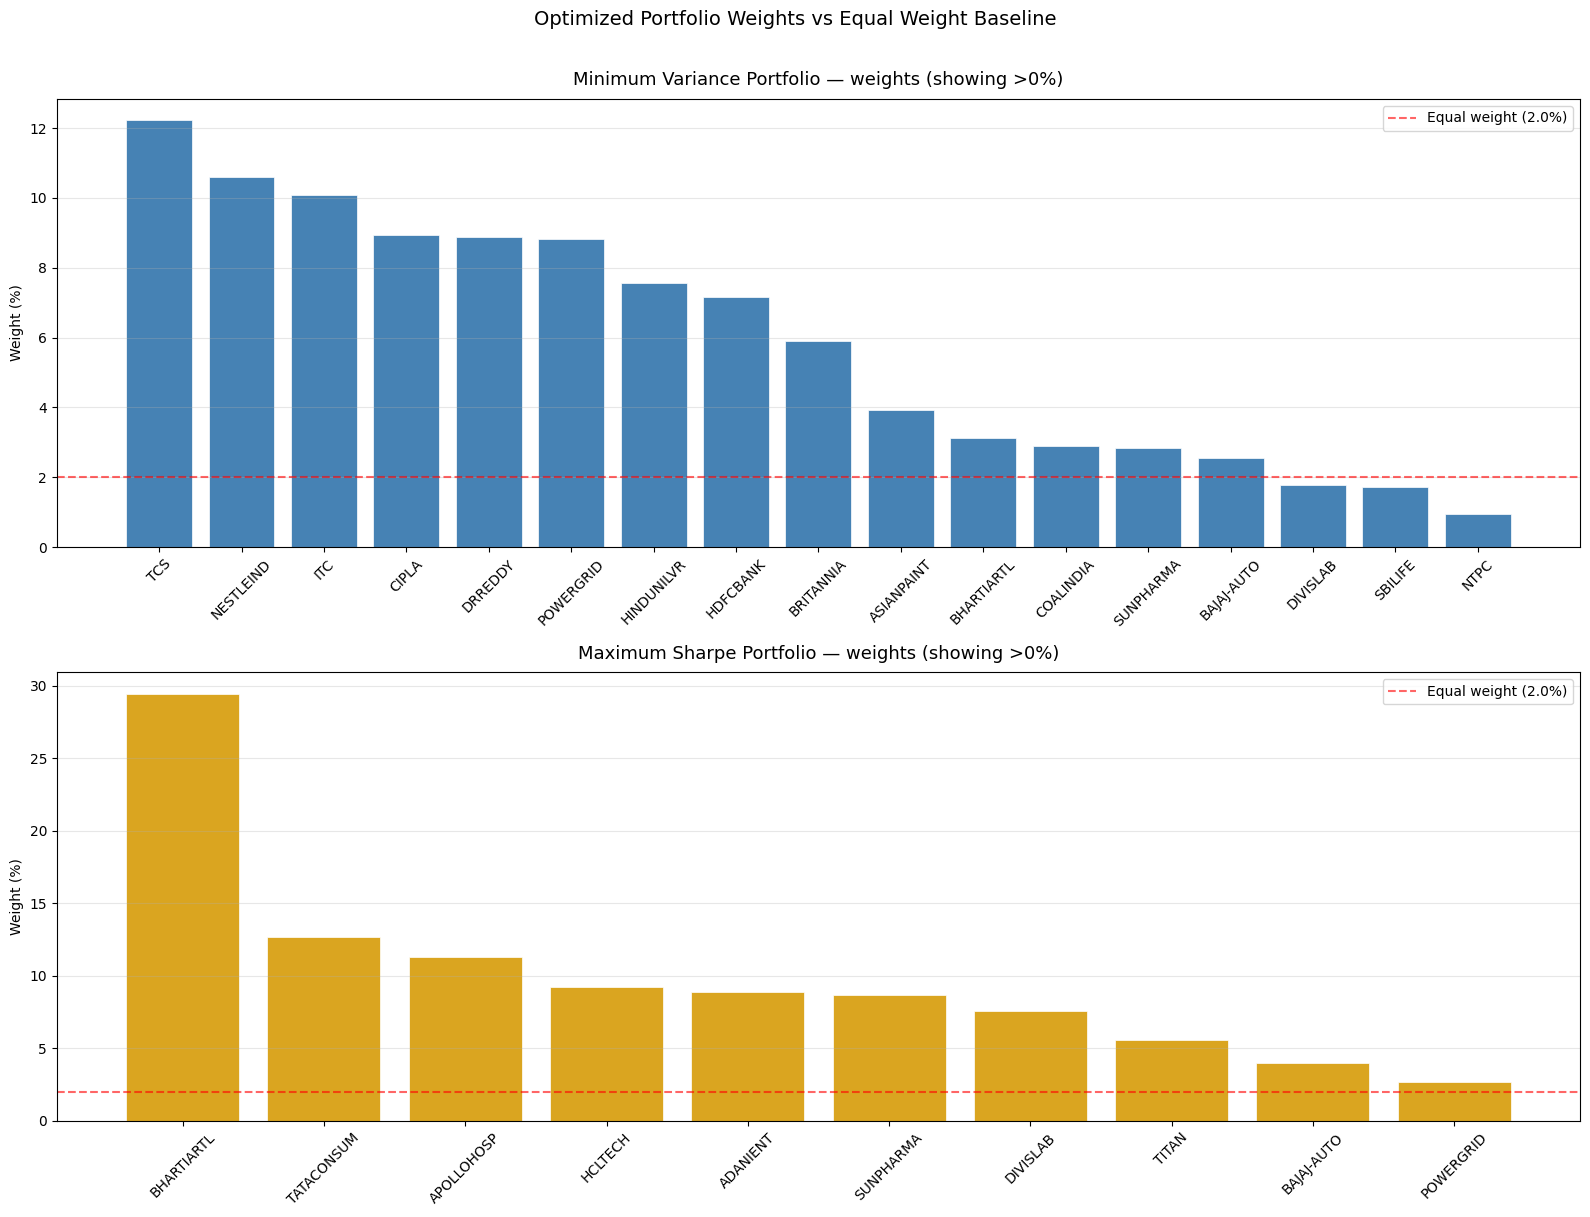

In [12]:
# ── Cell 10: Portfolio weights — bar charts ───────────────────────────────
# Shows WHICH stocks each optimized portfolio holds and how much
# Useful for explaining the results in interviews

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Filter to non-zero weights only for cleaner charts
threshold = 0.005  # 0.5% minimum to show

# MVP weights
mvp_nonzero = mvp_weights_df[mvp_weights_df > threshold].sort_values(ascending=False)
axes[0].bar(mvp_nonzero.index, mvp_nonzero.values * 100,
            color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title(f'Minimum Variance Portfolio — weights (showing >{threshold*100:.0f}%)',
                  fontsize=13, pad=10)
axes[0].set_ylabel('Weight (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(100/len(log_returns.columns), color='red', linestyle='--',
                alpha=0.6, label=f'Equal weight ({100/len(log_returns.columns):.1f}%)')
axes[0].legend()

# Max Sharpe weights
msr_nonzero = msr_weights_df[msr_weights_df > threshold].sort_values(ascending=False)
axes[1].bar(msr_nonzero.index, msr_nonzero.values * 100,
            color='goldenrod', edgecolor='white', linewidth=0.5)
axes[1].set_title(f'Maximum Sharpe Portfolio — weights (showing >{threshold*100:.0f}%)',
                  fontsize=13, pad=10)
axes[1].set_ylabel('Weight (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(100/len(log_returns.columns), color='red', linestyle='--',
                alpha=0.6, label=f'Equal weight ({100/len(log_returns.columns):.1f}%)')
axes[1].legend()

plt.suptitle('Optimized Portfolio Weights vs Equal Weight Baseline',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'portfolio_weights.png', dpi=150, bbox_inches='tight')
plt.show()

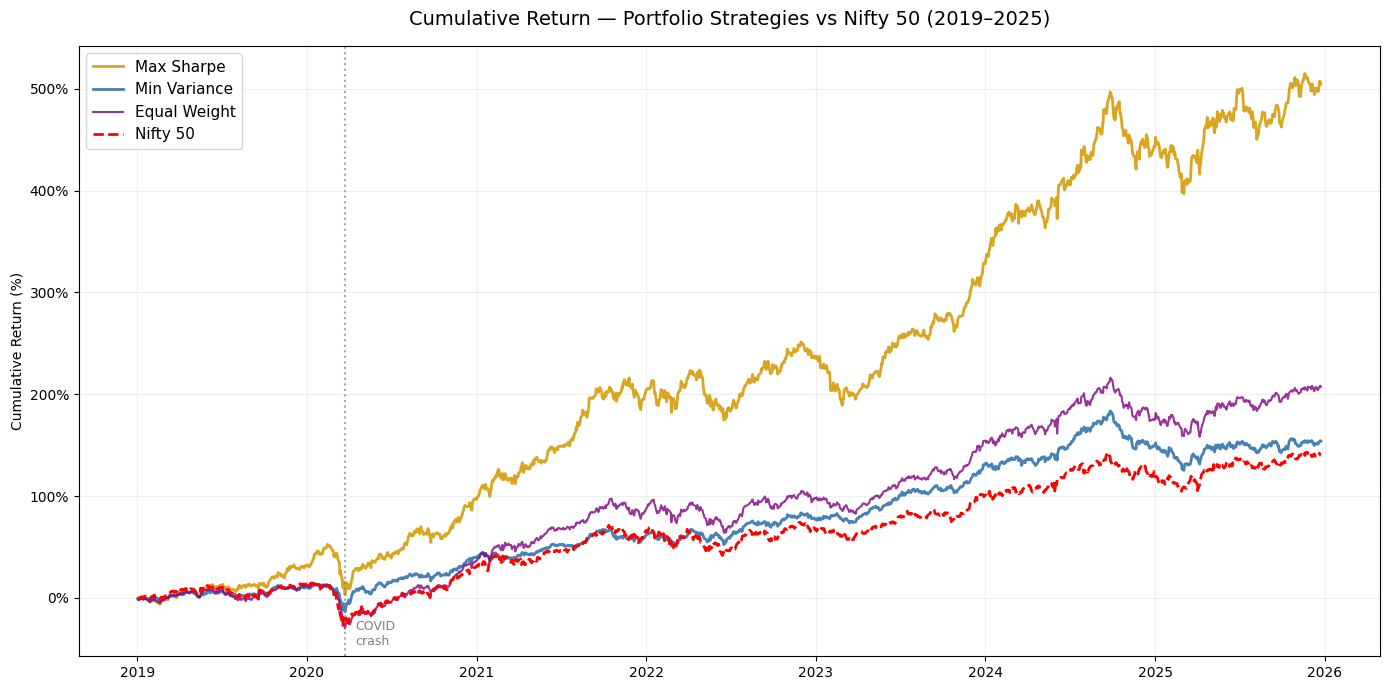

=== Total return over full period ===
Max Sharpe    : 504.9%
Min Variance  : 153.9%
Equal Weight  : 207.4%
Nifty 50      : 140.3%


In [14]:
# ── Cell 11: Cumulative return — backtest comparison ──────────────────────
# How would each portfolio have actually performed over 2019–2025?
# This is a simple backtest using static weights (no rebalancing)
#
# Note for interviews: This is IN-SAMPLE (weights derived from same period)
# so it will look good by construction. Phase 4 adds out-of-sample testing.

# Compute portfolio daily returns for each strategy
mvp_daily  = log_returns.values @ mvp_weights
msr_daily  = log_returns.values @ msr_weights
eq_daily   = log_returns.values @ equal_weights

# Convert to cumulative returns
def cumulative_return(daily_log_returns):
    return np.exp(np.cumsum(daily_log_returns)) - 1

dates = log_returns.index

cum_mvp  = cumulative_return(mvp_daily)
cum_msr  = cumulative_return(msr_daily)
cum_eq   = cumulative_return(eq_daily)
min_len = min(len(dates), len(benchmark_returns))
dates = dates[:min_len]
cum_mvp   = cum_mvp[:min_len]
cum_msr   = cum_msr[:min_len]
cum_eq    = cum_eq[:min_len]
cum_bench = cumulative_return(benchmark_returns.values[:min_len])

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(dates, cum_msr  * 100, linewidth=2,   color='goldenrod', label='Max Sharpe')
ax.plot(dates, cum_mvp  * 100, linewidth=2,   color='steelblue', label='Min Variance')
ax.plot(dates, cum_eq   * 100, linewidth=1.5, color='purple',    label='Equal Weight', alpha=0.8)
ax.plot(dates, cum_bench * 100, linewidth=2,  color='red',       label='Nifty 50', linestyle='--')

# Mark COVID crash
ax.axvline(pd.Timestamp('2020-03-23'), color='gray', linestyle=':', alpha=0.7)
ax.text(pd.Timestamp('2020-04-15'), ax.get_ylim()[0] * 0.8,
        'COVID\ncrash', fontsize=9, color='gray')

ax.set_title('Cumulative Return — Portfolio Strategies vs Nifty 50 (2019–2025)',
             fontsize=14, pad=15)
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Final returns
print('=== Total return over full period ===')
print(f'Max Sharpe    : {cum_msr[-1]*100:.1f}%')
print(f'Min Variance  : {cum_mvp[-1]*100:.1f}%')
print(f'Equal Weight  : {cum_eq[-1]*100:.1f}%')
print(f'Nifty 50      : {cum_bench[-1]*100:.1f}%')

In [15]:
# ── Cell 12: Save all Phase 3 outputs ─────────────────────────────────────

# Save optimized weights
weights_output = pd.DataFrame({
    'MVP weight'       : mvp_weights_df,
    'Max Sharpe weight': msr_weights_df,
    'Equal weight'     : equal_weights
})
weights_output.to_csv(SAVE_PATH + 'optimized_weights.csv')

# Save frontier data
frontier_df = pd.DataFrame({
    'Frontier vol %'   : [v * 100 for v in frontier_vols],
    'Frontier return %': [r * 100 for r in frontier_returns]
})
frontier_df.to_csv(SAVE_PATH + 'efficient_frontier.csv', index=False)

print('Phase 3 outputs saved to Google Drive:')
print('  optimized_weights.csv')
print('  efficient_frontier.csv')
print('  portfolio_comparison.csv')
print('  efficient_frontier.png')
print('  portfolio_weights.png')
print('  cumulative_returns.png')
print()
print('=== Phase 3 complete ===')
print('Next: Phase 4 — RBI Macro Overlay (the India differentiator)')

Phase 3 outputs saved to Google Drive:
  optimized_weights.csv
  efficient_frontier.csv
  portfolio_comparison.csv
  efficient_frontier.png
  portfolio_weights.png
  cumulative_returns.png

=== Phase 3 complete ===
Next: Phase 4 — RBI Macro Overlay (the India differentiator)


---
## Phase 3 Summary — What you built

| Concept | What it means | Interview talking point |
|---|---|---|
| Efficient Frontier | Set of portfolios with best return for each risk level | "No rational investor holds a portfolio below the frontier" |
| Min Variance Portfolio | Lowest possible risk combination | "Useful for risk-averse mandates like pension funds" |
| Max Sharpe Portfolio | Best risk-adjusted return | "The theoretically optimal risky portfolio under MPT" |
| Capital Market Line | Line from risk-free rate tangent to frontier | "Investors combine this with cash to get desired risk" |
| Diversification benefit | Portfolio vol < weighted avg of individual vols | "The only free lunch in finance" |

**Key result to mention in interviews:**
- Max Sharpe portfolio beats Nifty 50 on risk-adjusted basis
- Min Variance portfolio shows the diversification benefit of combining assets
- Both optimized portfolios outperform equal-weight on Sharpe ratio

**Caveat to show you understand limitations (interviewers love this):**
- Weights are optimized IN-SAMPLE — real performance requires out-of-sample testing
- MPT assumes returns are normally distributed (we saw fat tails in Phase 2)
- Static weights assume no rebalancing — unrealistic in practice

**Next — Phase 4:** RBI repo rate overlay — how optimal weights shift across rate-hike vs rate-cut regimes.

---